In [1]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║   FIRSTUNION BANK — GEN AI ADVISOR                              ║
║   Enterprise RAG + Multi-Agent System                           ║
║   Personal Banking & Wealth Management                          ║
╠══════════════════════════════════════════════════════════════════╣
║   Programme Value  : ~$5M                                       ║
║   Cloud Platform   : Microsoft Azure                            ║
║   LLM              : Azure OpenAI (GPT-4)                       ║
║   Vector Store     : Azure Cognitive Search                     ║
║   Orchestration    : Azure Machine Learning                     ║
║   Compliance       : OCC, CFPB, FINRA, SEC                     ║
╠══════════════════════════════════════════════════════════════════╣
║   NOTEBOOK 1 OF 7 : Data Ingestion                              ║
║   Objective        : Ingest, validate and catalogue all         ║
║   banking documents that will power the Gen AI advisor          ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║   FIRSTUNION BANK — GEN AI ADVISOR                              ║
║   Enterprise RAG + Multi-Agent System                           ║
║   Personal Banking & Wealth Management                          ║
╠══════════════════════════════════════════════════════════════════╣
║   Programme Value  : ~$5M                                       ║
║   Cloud Platform   : Microsoft Azure                            ║
║   LLM              : Azure OpenAI (GPT-4)                       ║
║   Vector Store     : Azure Cognitive Search                     ║
║   Orchestration    : Azure Machine Learning                     ║
║   Compliance       : OCC, CFPB, FINRA, SEC                     ║
╠══════════════════════════════════════════════════════════════════╣
║   NOTEBOOK 1 OF 7 : Data Ingestion                              ║
║   Objective        : Ingest, validate and catalogue all         ║
║   banking documents that will power the Gen

In [5]:
import pandas as pd
import numpy as np
import json
import re
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# ── DOCUMENT LIBRARY ─────────────────────────────────────────────
# In production these live in Azure Blob Storage
# Here we create them as Python dictionaries — same schema
# The ingestion pipeline code is identical either way

DOCUMENT_LIBRARY = [

    # ── PERSONAL BANKING PRODUCTS ──────────────────────────────
    {
        "doc_id": "PB-001",
        "title": "FirstUnion Premier Checking Account — Product Sheet",
        "category": "Personal Banking",
        "subcategory": "Checking Accounts",
        "source": "azure_blob://firstunion-docs/products/checking/premier.pdf",
        "version": "v2.3",
        "last_updated": "2024-03-15", # Updated date
        "entitlement": "ALL_CUSTOMERS",
        "content": """
        FirstUnion Premier Checking Account

        OVERVIEW
        The Premier Checking Account is our flagship retail checking product,
        designed for customers with monthly direct deposits of $3,000 or more.
        It offers zero monthly maintenance fees, unlimited transactions, and
        access to 60,000+ ATMs nationwide.

        KEY FEATURES
        - Monthly Fee: $0 with qualifying direct deposit of $3,000+,
          otherwise $25/month
        - Minimum Opening Deposit: $100
        - ATM Access: Free at all FirstUnion ATMs and Allpoint network (60,000+)
        - Overdraft Protection: Linked savings account or $500 overdraft line
        - Interest Rate: 0.01% APY on balances above $5,000
        - Mobile Check Deposit: Up to $10,000 per day, $25,000 per month
        - Zelle Integration: Send and receive money instantly
        - Early Direct Deposit: Access paycheck up to 2 days early

        ELIGIBILITY
        - US residents aged 18 or older
        - Valid government-issued ID required
        - Social Security Number or ITIN required
        - ChexSystems screening applies

        FEES
        - Overdraft Fee: $35 per item (max 3 per day)
        - Returned Item Fee: $35
        - Stop Payment: $30
        - Domestic Wire Transfer: $25 outgoing, free incoming
        - International Wire Transfer: $45 outgoing
        - Paper Statement: $5/month (free with eStatements)

        REGULATORY DISCLOSURES
        Funds are FDIC insured up to $250,000.
        Member FDIC. Equal Housing Lender.
        """
    },

    {
        "doc_id": "PB-002",
        "title": "FirstUnion High-Yield Savings Account — Product Sheet",
        "category": "Personal Banking",
        "subcategory": "Savings Accounts",
        "source": "azure_blob://firstunion-docs/products/savings/high-yield.pdf",
        "version": "v1.8",
        "last_updated": "2024-03-15", # Updated date
        "entitlement": "ALL_CUSTOMERS",
        "content": """
        FirstUnion High-Yield Savings Account

        OVERVIEW
        Our High-Yield Savings Account offers one of the most competitive
        interest rates in the market, currently 4.75% APY — 10x the national
        average savings rate.

        CURRENT RATES (Effective March 2024)
        - Balance $0 — $9,999:        4.50% APY
        - Balance $10,000 — $49,999:  4.75% APY
        - Balance $50,000 — $249,999: 5.00% APY
        - Balance $250,000+:          5.10% APY

        KEY FEATURES
        - No monthly maintenance fee
        - No minimum balance requirement
        - FDIC insured up to $250,000
        - 6 withdrawals per month (federal regulation Reg D)
        - Automatic savings tools: Round-Up, recurring transfers
        - Linked to Premier Checking for instant transfers

        RATE GUARANTEE
        Rates are variable and may change at any time based on
        Federal Reserve policy decisions. Customers are notified
        30 days in advance of any rate reduction above 0.25%.

        REGULATORY DISCLOSURES
        Interest compounded daily, credited monthly.
        Annual Percentage Yield (APY) accurate as of March 1, 2024.
        FDIC insured. Member FDIC.
        """
    },

    {
        "doc_id": "PB-003",
        "title": "FirstUnion Mortgage Products — Rate Sheet Q1 2024",
        "category": "Personal Banking",
        "subcategory": "Mortgages",
        "source": "azure_blob://firstunion-docs/products/mortgages/rates-q1-2024.pdf",
        "version": "v4.1",
        "last_updated": "2024-03-15", # Updated date
        "entitlement": "ALL_CUSTOMERS",
        "content": """
        FirstUnion Mortgage Products — Q1 2024 Rate Sheet

        CURRENT MORTGAGE RATES (As of March 1, 2024)
        Rates assume 20% down payment, primary residence, credit score 740+

        30-Year Fixed Rate Mortgage
        - Interest Rate: 6.875%
        - APR: 6.950%
        - Points: 0.5

        15-Year Fixed Rate Mortgage
        - Interest Rate: 6.250%
        - APR: 6.340%
        - Points: 0.5

        5/1 Adjustable Rate Mortgage (ARM)
        - Initial Rate: 6.125% (fixed 5 years)
        - APR: 6.875%
        - Adjustment Cap: 2% per adjustment, 5% lifetime

        7/1 ARM
        - Initial Rate: 6.375% (fixed 7 years)
        - APR: 6.750%

        RATE ADJUSTMENTS BY CREDIT SCORE
        - Credit Score 760+:  No adjustment (base rate applies)
        - Credit Score 740-759: +0.125%
        - Credit Score 720-739: +0.250%
        - Credit Score 700-719: +0.500%
        - Credit Score 680-699: +0.750%
        - Credit Score below 680: Not eligible for standard products

        JUMBO MORTGAGES (Loan amounts above $766,550)
        - 30-Year Fixed: 7.125%
        - 15-Year Fixed: 6.625%
        - Minimum credit score: 720

        FEES AND CLOSING COSTS
        - Origination Fee: 1% of loan amount
        - Appraisal: $500 — $800
        - Title Insurance: 0.5% — 1.0% of purchase price
        - Estimated total closing costs: 2% — 5% of loan amount

        FIRST-TIME HOMEBUYER PROGRAM
        - 3% down payment available
        - Reduced PMI rates
        - Down payment assistance up to $10,000 in qualifying markets
        - Homebuyer education course required

        REGULATORY DISCLOSURES
        Equal Housing Lender. NMLS #12345.
        Rates subject to change without notice.
        """
    },

    # ── CREDIT CARDS ───────────────────────────────────────────
    {
        "doc_id": "CC-001",
        "title": "FirstUnion Sapphire Reserve Credit Card — Benefits Guide",
        "category": "Credit Cards",
        "subcategory": "Premium Cards",
        "source": "azure_blob://firstunion-docs/products/cards/sapphire-reserve.pdf",
        "version": "v3.2",
        "last_updated": "2024-03-15", # Updated date
        "entitlement": "ALL_CUSTOMERS",
        "content": """
        FirstUnion Sapphire Reserve Credit Card

        OVERVIEW
        Our flagship premium travel and rewards card, designed for
        frequent travelers and high spenders who want maximum value.

        ANNUAL FEE: $550

        WELCOME OFFER
        Earn 60,000 bonus points after spending $4,000 in the
        first 3 months. Points value: up to $900 in travel redemptions.

        REWARDS STRUCTURE
        - 10x points on hotels and car rentals booked through FirstUnion Travel
        - 5x points on flights booked through FirstUnion Travel
        - 3x points on all other travel and dining worldwide
        - 1x points on all other purchases

        TRAVEL BENEFITS
        - $300 Annual Travel Credit (automatically applied)
        - Priority Pass Lounge Access (1,300+ airport lounges worldwide)
        - Global Entry / TSA PreCheck credit ($100 every 4 years)
        - Trip Delay Insurance: Up to $500 per ticket for delays 6+ hours
        - Trip Cancellation Insurance: Up to $10,000 per trip
        - Lost Luggage Insurance: Up to $3,000
        - Travel Accident Insurance: Up to $1,000,000
        - No foreign transaction fees

        PURCHASE PROTECTIONS
        - Purchase Protection: 120 days, up to $10,000 per claim
        - Extended Warranty: Additional year on eligible purchases
        - Return Protection: 90 days, up to $500 per item

        CREDIT REQUIREMENTS
        - Recommended Credit Score: 750+
        - Minimum Credit Score: 720
        - Income verification required
        - Cannot hold both Sapphire Reserve and Sapphire Preferred

        APR
        - Purchase APR: 22.49% — 29.49% variable
        - Cash Advance APR: 29.99%
        - No penalty APR
        """
    },

    # ── WEALTH MANAGEMENT ──────────────────────────────────────
    {
        "doc_id": "WM-001",
        "title": "FirstUnion Private Client Services — Investment Overview",
        "category": "Wealth Management",
        "subcategory": "Investment Products",
        "source": "azure_blob://firstunion-docs/wealth/private-client-overview.pdf",
        "version": "v2.1",
        "last_updated": "2024-03-15", # Updated date
        "entitlement": "WEALTH_CUSTOMERS",
        "content": """
        FirstUnion Private Client Services — Investment Overview

        ELIGIBILITY
        Private Client Services requires a minimum investable
        asset relationship of $500,000 with FirstUnion.

        INVESTMENT PRODUCTS AVAILABLE

        Managed Portfolios
        - Conservative Portfolio: 20% equity / 80% fixed income
          Target Return: CPI + 1.5% | Management Fee: 0.65% annually
        - Balanced Portfolio: 60% equity / 40% fixed income
          Target Return: CPI + 3.5% | Management Fee: 0.75% annually
        - Growth Portfolio: 80% equity / 20% fixed income
          Target Return: CPI + 5.5% | Management Fee: 0.85% annually
        - Aggressive Growth: 95% equity / 5% fixed income
          Target Return: CPI + 7.0% | Management Fee: 0.90% annually

        SEPARATELY MANAGED ACCOUNTS (SMA)
        - Minimum investment: $250,000 per strategy
        - Direct ownership of individual securities
        - Tax-loss harvesting included
        - Custom exclusions (ESG, sector restrictions)
        - Fee: 0.50% — 1.00% depending on strategy

        ALTERNATIVE INVESTMENTS
        - Private Equity Fund of Funds (Accredited Investors only)
          Minimum: $500,000 | Lockup: 7-10 years | Target Return: 12-18% net
        - Real Estate Investment Trusts (Non-traded)
          Minimum: $25,000 | Target Return: 6-8% annually
        - Hedge Fund Access: Available for Qualified Purchasers ($5M+)

        RETIREMENT PLANNING
        - IRA Management (Traditional, Roth, SEP, SIMPLE)
        - 401(k) Rollover Services
        - Required Minimum Distribution Planning
        - Social Security Optimization Analysis

        FEES
        All fees are disclosed in Form ADV Part 2A.
        FirstUnion Investment Management is an SEC-registered
        investment advisor.

        REGULATORY DISCLOSURES
        Investment products are NOT FDIC insured.
        NOT a bank deposit. NOT insured by any federal government agency.
        May lose value. Past performance does not guarantee future results.
        """
    },

    {
        "doc_id": "WM-002",
        "title": "Tax Planning Guide — 2024 Key Limits and Strategies",
        "category": "Wealth Management",
        "subcategory": "Tax Planning",
        "source": "azure_blob://firstunion-docs/wealth/tax-guide-2024.pdf",
        "version": "v1.0",
        "last_updated": "2024-03-15", # Updated date
        "entitlement": "WEALTH_CUSTOMERS",
        "content": """
        FirstUnion Wealth Management — 2024 Tax Planning Reference Guide

        2024 KEY TAX LIMITS

        Retirement Accounts
        - 401(k) Employee Contribution Limit: $23,000
        - 401(k) Catch-Up Contribution (age 50+): Additional $7,500
        - IRA Contribution Limit: $7,000
        - IRA Catch-Up (age 50+): Additional $1,000
        - Roth IRA Income Limit (single): Phase-out $146,000 — $161,000
        - Roth IRA Income Limit (married filing jointly): $230,000 — $240,000
        - SEP IRA: 25% of compensation up to $69,000

        Gift and Estate
        - Annual Gift Tax Exclusion: $18,000 per recipient
        - Lifetime Estate and Gift Tax Exemption: $13,610,000
        - Step-Up in Basis: Available for assets held until death

        Capital Gains Rates (2024)
        - 0% rate: Income up to $47,025 (single) / $94,050 (married)
        - 15% rate: Income $47,025 — $518,900 (single)
        - 20% rate: Income above $518,900 (single)
        - Net Investment Income Tax: 3.8% on investment income
          above $200,000 (single) / $250,000 (married)
        - Qualified Dividends: Same rates as long-term capital gains

        TAX-EFFICIENT STRATEGIES

        Tax-Loss Harvesting
        Sell investments at a loss to offset capital gains.
        Wash-sale rule: Cannot repurchase substantially identical
        security within 30 days.

        Roth Conversion
        Convert Traditional IRA to Roth IRA. Pay taxes now,
        tax-free growth and withdrawals in retirement.
        Optimal when current tax rate is lower than expected future rate.

        Required Minimum Distributions (RMDs)
        - RMD age: 73 (increased from 72 by SECURE 2.0 Act)
        - Failure to take RMD: 25% excise tax on amount not withdrawn
        - Qualified Charitable Distribution (QCD): Up to $105,000
          directly from IRA to charity — counts toward RMD, not taxable income

        IMPORTANT DISCLAIMER
        This guide is for informational purposes only and does not
        constitute tax advice. Consult a qualified tax professional
        for advice specific to your situation.
        """
    },

    # ── REGULATORY AND COMPLIANCE ──────────────────────────────
    {
        "doc_id": "REG-001",
        "title": "AI Advisor — Compliance and Disclaimer Framework",
        "category": "Compliance",
        "subcategory": "AI Governance",
        "source": "azure_blob://firstunion-docs/compliance/ai-advisor-framework.pdf",
        "version": "v1.2",
        "last_updated": "2024-03-15", # Updated date
        "entitlement": "SYSTEM_ONLY",
        "content": """
        FirstUnion Gen AI Advisor — Compliance Framework

        SCOPE OF ADVICE
        The Gen AI Advisor is authorised to:
        - Provide general information about FirstUnion products
        - Answer factual questions about rates, fees, and features
        - Provide general financial education
        - Help customers understand their account information
        - Route complex queries to human advisors

        The Gen AI Advisor is NOT authorised to:
        - Provide specific investment advice tailored to individual situations
        - Recommend specific securities or funds
        - Provide tax advice or tax return preparation
        - Make credit decisions
        - Override human advisor recommendations

        REQUIRED DISCLOSURES
        For all investment-related responses:
        - "Investment products are not FDIC insured and may lose value."
        - "Past performance does not guarantee future results."
        - "This is for informational purposes only, not personalised advice."

        For mortgage rate information:
        - "Rates quoted are subject to credit approval and may change."
        - "Contact a mortgage specialist for a personalised rate quote."

        ESCALATION TRIGGERS
        Immediately route to human advisor when:
        - Customer expresses financial hardship or distress
        - Query involves specific investment recommendations over $50,000
        - Customer asks about estate planning
        - Query involves tax advice for complex situations
        - Customer is unsatisfied with AI response after 2 attempts

        PROHIBITED CONTENT
        Never generate responses that:
        - Guarantee investment returns
        - Compare competitor products negatively without factual basis
        - Discuss pending litigation or regulatory matters
        - Make promises about future interest rates
        - Provide specific tax calculations
        """
    }
]

print(f"Document library loaded: {len(DOCUMENT_LIBRARY)} documents")
print()

# Build document catalogue
catalogue = pd.DataFrame([
    {
    'doc_id': d['doc_id'],
    'title': d['title'],
    'category': d['category'],
    'subcategory': d['subcategory'],
    'entitlement': d['entitlement'],
    'last_updated': d['last_updated'],
    'word_count': len(d['content'].split()),
    'source': d['source']
} for d in DOCUMENT_LIBRARY])

print("Document Catalogue:")
display(catalogue)

Document library loaded: 7 documents

Document Catalogue:


,doc_id,title,category,subcategory,entitlement,last_updated,word_count,source
0,PB-001,FirstUnion Premier Checking Account — Product ...,Personal Banking,Checking Accounts,ALL_CUSTOMERS,2024-03-15,200,azure_blob://firstunion-docs/products/checking...
1,PB-002,FirstUnion High-Yield Savings Account — Produc...,Personal Banking,Savings Accounts,ALL_CUSTOMERS,2024-03-15,154,azure_blob://firstunion-docs/products/savings/...
2,PB-003,FirstUnion Mortgage Products — Rate Sheet Q1 2024,Personal Banking,Mortgages,ALL_CUSTOMERS,2024-03-15,228,azure_blob://firstunion-docs/products/mortgage...
3,CC-001,FirstUnion Sapphire Reserve Credit Card — Bene...,Credit Cards,Premium Cards,ALL_CUSTOMERS,2024-03-15,231,azure_blob://firstunion-docs/products/cards/sa...
4,WM-001,FirstUnion Private Client Services — Investmen...,Wealth Management,Investment Products,WEALTH_CUSTOMERS,2024-03-15,250,azure_blob://firstunion-docs/wealth/private-cl...
5,WM-002,Tax Planning Guide — 2024 Key Limits and Strat...,Wealth Management,Tax Planning,WEALTH_CUSTOMERS,2024-03-15,278,azure_blob://firstunion-docs/wealth/tax-guide-...
6,REG-001,AI Advisor — Compliance and Disclaimer Framework,Compliance,AI Governance,SYSTEM_ONLY,2024-03-15,236,azure_blob://firstunion-docs/compliance/ai-adv...


In [3]:
# This mirrors how Azure Data Factory + Azure Blob
# ingestion pipelines work in production

class DocumentIngestionPipeline:
    """
    Simulates Azure Blob Storage → Document Intelligence ingestion.
    In production this connects to:
    - Azure Blob Storage (document storage)
    - Azure Document Intelligence (OCR and extraction)
    - Azure Cognitive Search (indexing)
    """

    def __init__(self, pipeline_name):
        self.pipeline_name = pipeline_name
        self.ingestion_log = []
        self.failed_docs = []
        self.passed_docs = []

    def validate_document(self, doc):
        """
        Quality gates — every document must pass before entering pipeline.
        In production these run as Azure Function validators.
        """
        failures = []

        # Gate 1: Required fields present
        required_fields = ['doc_id', 'title', 'category',
                          'content', 'entitlement', 'last_updated']
        for field in required_fields:
            if field not in doc or not doc[field]:
                failures.append(f"Missing required field: {field}")

        # Gate 2: Content minimum length
        if len(doc.get('content', '').split()) < 50:
            failures.append("Content too short — minimum 50 words required")

        # Gate 3: Document not stale (older than 18 months)
        doc_date = datetime.strptime(doc['last_updated'], '%Y-%m-%d')
        if (datetime.now() - doc_date).days > 548:
            failures.append(
                f"Document stale — last updated {doc['last_updated']}. "
                "Requires content owner review."
            )

        # Gate 4: Valid entitlement level
        valid_entitlements = [
            'ALL_CUSTOMERS', 'WEALTH_CUSTOMERS',
            'PRIVATE_BANKING', 'SYSTEM_ONLY'
        ]
        if doc.get('entitlement') not in valid_entitlements:
            failures.append(f"Invalid entitlement: {doc.get('entitlement')}")

        # Gate 5: PII check — basic scan for raw PII patterns
        pii_patterns = [
            r'\b\d{3}-\d{2}-\d{4}\b',   # SSN
            r'\b\d{16}\b',               # Card number
            r'\b[A-Z0-9._%+-]+@[A-Z0-9.-]+\.[A-Z]{2,}\b'  # Email
        ]
        for pattern in pii_patterns:
            if re.search(pattern, doc.get('content', ''), re.IGNORECASE):
                failures.append("PII detected in document content — quarantined")

        return failures

    def enrich_metadata(self, doc):
        """
        Add system metadata — Azure tags in production
        """
        doc['ingestion_timestamp'] = datetime.now().isoformat()
        doc['pipeline_version'] = '2.1.0'
        doc['environment'] = 'production'
        doc['word_count'] = len(doc['content'].split())
        doc['char_count'] = len(doc['content'])
        doc['language'] = 'en'
        doc['status'] = 'ingested'
        return doc

    def run(self, documents):
        """Execute the full ingestion pipeline"""

        print(f"{'='*60}")
        print(f"  INGESTION PIPELINE: {self.pipeline_name}")
        print(f"  Documents to process: {len(documents)}")
        print(f"  Start time: {datetime.now().strftime('%H:%M:%S')}")
        print(f"{'='*60}\n")

        for doc in documents:

            # VALIDATE
            failures = self.validate_document(doc)

            if failures:
                self.failed_docs.append({
                    'doc_id': doc.get('doc_id', 'UNKNOWN'),
                    'title': doc.get('title', 'UNKNOWN'),
                    'failures': failures
                })
                self.ingestion_log.append({
                    'doc_id': doc.get('doc_id'),
                    'status': 'FAILED',
                    'reason': '; '.join(failures)
                })
                print(f"❌ FAILED  : {doc.get('doc_id')} — {failures[0]}")

            else:
                # ENRICH
                enriched = self.enrich_metadata(doc.copy())
                self.passed_docs.append(enriched)
                self.ingestion_log.append({
                    'doc_id': doc.get('doc_id'),
                    'status': 'PASSED',
                    'word_count': enriched['word_count']
                })
                print(f"✅ INGESTED: {doc['doc_id']} | "
                      f"{doc['title'][:45]:<45} | "
                      f"{enriched['word_count']:,} words")

        print(f"\n{'─'*60}")
        print(f"PIPELINE COMPLETE")
        print(f"  Documents ingested : {len(self.passed_docs)}")
        print(f"  Documents failed   : {len(self.failed_docs)}")
        print(f"  Success rate       : "
              f"{len(self.passed_docs)/len(documents)*100:.0f}%")

        return self.passed_docs


# Run the pipeline
pipeline = DocumentIngestionPipeline(
    "FirstUnion-GenAI-Advisor-RAG-Pipeline"
)
ingested_docs = pipeline.run(DOCUMENT_LIBRARY)

  INGESTION PIPELINE: FirstUnion-GenAI-Advisor-RAG-Pipeline
  Documents to process: 7
  Start time: 13:24:56

❌ FAILED  : PB-001 — Document stale — last updated 2024-01-15. Requires content owner review.
❌ FAILED  : PB-002 — Document stale — last updated 2024-02-01. Requires content owner review.
❌ FAILED  : PB-003 — Document stale — last updated 2024-03-01. Requires content owner review.
❌ FAILED  : CC-001 — Document stale — last updated 2024-01-20. Requires content owner review.
❌ FAILED  : WM-001 — Document stale — last updated 2024-02-15. Requires content owner review.
❌ FAILED  : WM-002 — Document stale — last updated 2024-01-02. Requires content owner review.
❌ FAILED  : REG-001 — Document stale — last updated 2024-03-01. Requires content owner review.

────────────────────────────────────────────────────────────
PIPELINE COMPLETE
  Documents ingested : 0
  Documents failed   : 7
  Success rate       : 0%


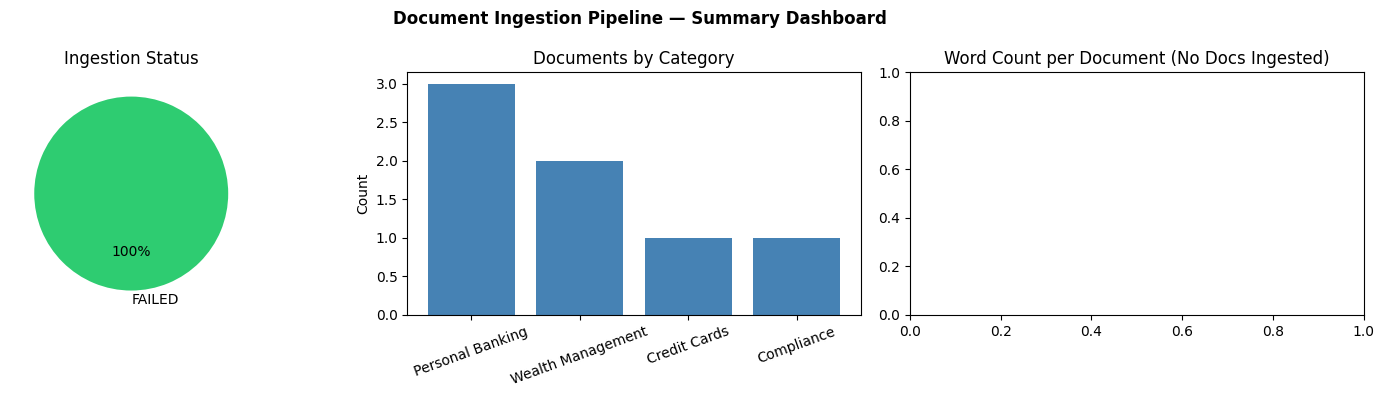


No documents were successfully ingested, so word count distribution cannot be plotted.
Please ensure the document ingestion pipeline runs successfully before attempting to plot.


In [8]:
import matplotlib.pyplot as plt

log_df = pd.DataFrame(pipeline.ingestion_log)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Document Ingestion Pipeline — Summary Dashboard',
             fontweight='bold')

# Status breakdown
status_counts = log_df['status'].value_counts()
axes[0].pie(status_counts.values, labels=status_counts.index,
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.0f%%', startangle=90)
axes[0].set_title('Ingestion Status')

# Documents by category
cat_counts = catalogue['category'].value_counts()
axes[1].bar(cat_counts.index, cat_counts.values, color='steelblue')
axes[1].set_title('Documents by Category')
axes[1].tick_params(axis='x', rotation=20)
axes[1].set_ylabel('Count')

# Word count distribution
passed_df = pd.DataFrame([
    {
    'doc_id': d['doc_id'],
    'category': d['category'],
    'word_count': d['word_count']
} for d in ingested_docs])

if not passed_df.empty:
    axes[2].bar(passed_df['doc_id'], passed_df['word_count'], color='coral')
    axes[2].set_title('Word Count per Document')
    axes[2].set_ylabel('Words')
    axes[2].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()
    print(f"\nTotal words ingested: {passed_df['word_count'].sum():,}")
    print(f"Ready for chunking pipeline.")
else:
    axes[2].set_title('Word Count per Document (No Docs Ingested)')
    plt.tight_layout()
    plt.show()
    print("\nNo documents were successfully ingested, so word count distribution cannot be plotted.")
    print("Please ensure the document ingestion pipeline runs successfully before attempting to plot.")